In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay
)

from config import (
    TARGET_COLUMN,
    METRICS_DIR
)

from src.data.data_loader import load_supervised_features

from src.eda.eda_utils import (
    get_dataframe_overview,
    get_target_summary
)

from src.models.supervised_models import SupervisedModelTrainer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

The scope of this notebook is to train and evaluate binary classification models for default-risk prediction.

Supervised modeling workflow uses the processed features created during preprocessing and future engineering steps.

The modeling approach in this notebook is:
* Use logistic regression as the baseline model
* Compare the baseline against benchmark non-linear models
* Evaluate models using metrics suitable for imbalanced binary classification
* Interpret the results from both statistical and credit-risk business prespectives

Main evaluation metrics are considered as PR-AUC, ROC-AUC, recall, precsion, f1-score, and balanced accuracy due to imbalanced minority class data structure.

#### **Supervised Features**

In [2]:
### loading features
# supervised features
supervised_features = load_supervised_features()
print(f'Supervised features shape: {supervised_features.shape}')
supervised_features.head()

Supervised features shape: (59472, 43)


,Loan To Value,Branch ID,Age,Employment Type,State,FICO Score,Number of Accounts,Number of Active Accounts,Number of Overdue Accounts,Current Balance Amount,Disbursed Amount,Instalment Amount,Number of Accounts Opened Last 6 Months,Average Account Age,Number of Inquiries,Target,DisbursementYear,DisbursementQuarter,DisbursementMonth,DaysSinceDisbursement,IsBureauExcluded,Legit FICO Scores,FICO Rating,FICO Rating Ordinal,HasNegativeCurrentBalance,HasZeroCurrentBalance,CurrentBalancePositiveAmount,InstalmentToDisbursedRatio,BalanceToDisbursedRatio,HasNoActiveAccounts,ActiveAccountRatio,OverdueAccountRatio,RecentlyOpenedAccountRatio,CreditHistoryAgeBand,AccountsPerCreditHistoryMonth,RecentlyOpenedAccountsPerCreditHistoryMonth,InquiryIntensityBand,InquiryPerCreditHistoryMonth,InquiryToAccountRatio,IsHighLTV,IsVeryHighLTV,Legit LTV,InstalmentToDisbursedAmount
0,88.17,18,53,Self employed,Louisiana,681,9,3.0,0,63727,100984,5571,1,9,0,0,2018,3,8,0,0,681.0,Good,3,0,0,1,0.055167,0.000010,0,0.333333,0.000000,0.111111,Young,1.000000,0.111111,No Inquiry,0.0,0.0,1,0,88.17,0.055167
1,83.78,13,39,Salaried,Tennessee,384,3,1.0,1,103435,100000,160963,0,36,0,1,2018,3,8,0,0,384.0,Poor,1,0,0,1,1.609630,0.000010,0,0.333333,0.333333,0.000000,Mature,0.083333,0.000000,No Inquiry,0.0,0.0,1,0,83.78,1.609630
2,74.89,63,28,Salaried,New Jersey,673,8,2.0,0,120985,130600,15820,1,1,0,0,2018,3,8,0,0,673.0,Good,3,0,0,1,0.121133,0.000008,0,0.250000,0.000000,0.125000,Very Young,8.000000,1.000000,No Inquiry,0.0,0.0,0,0,74.89,0.121133
3,73.65,67,35,Self employed,Nevada,16,1,0.0,0,0,0,0,0,6,0,0,2018,3,8,0,1,NaN,Bureau Excluded,0,0,1,1,NaN,NaN,1,0.000000,0.000000,0.000000,Young,0.166667,0.000000,No Inquiry,0.0,0.0,0,0,73.65,NaN
4,83.29,16,32,Salaried,Illinois,626,6,2.0,0,42588,51320,7916,3,4,0,0,2018,3,8,0,0,626.0,Fair,2,0,0,1,0.154248,0.000019,0,0.333333,0.000000,0.500000,Very Young,1.500000,0.750000,No Inquiry,0.0,0.0,1,0,83.29,0.154248


In [3]:
### supervised features - dataframe overview
overview = get_dataframe_overview(df = supervised_features)
overview

,dtype,missing_count,missing_rate,unique_count,unique_rate
InstalmentToDisbursedRatio,float64,11120,0.1870,29617,0.4980
InstalmentToDisbursedAmount,float64,11120,0.1870,29617,0.4980
BalanceToDisbursedRatio,float64,11120,0.1870,26575,0.4468
Legit FICO Scores,float64,6522,0.1097,561,0.0094
AccountsPerCreditHistoryMonth,float64,1809,0.0304,1114,0.0187
InquiryPerCreditHistoryMonth,float64,1809,0.0304,257,0.0043
RecentlyOpenedAccountsPerCreditHistoryMonth,float64,1809,0.0304,243,0.0041
ActiveAccountRatio,float64,222,0.0037,415,0.0070
Number of Active Accounts,float64,222,0.0037,36,0.0006
Legit LTV,float64,34,0.0006,5346,0.0899


In [4]:
### supervised features - target distribution
target_summary = get_target_summary(
    df = supervised_features,
    target_column = TARGET_COLUMN
)
target_summary

,count,ratio,percentage
Target,,,
0,50477,0.848752,84.875235
1,8995,0.151248,15.124765


#### **Modelling**

The model training workflow uses the SupervisedModelTrainer class. The trainer applier the same model preprocessing pipeline to each candidate baseline and benchmark classifiers, which
ensures that models are compared under a consistent preprocessing setup.

Preprocessing pipeline steps:
* numeric imputation
* robust scaling
* outlier handling
* one-hot encoding for low-cardinality categorical variables
* target encoding for high-cardinality categorical variables

Candidate models:
* Logistic Regression -> baseline
* Decision Tree
* Random Forest
* Gradient Boosting

Class imbalance is handled using stratified train-test split, class weights, and balanced sample weights for Gradient Boosting case. 

In [5]:
### supervised model - initialize trainer
trainer = SupervisedModelTrainer(
    target_column = TARGET_COLUMN,
    test_size = 0.2,
    random_state = 2,
    threshold = 0.5
)

# candidate models
candidate_models = trainer.get_candidate_models()
candidate_models

{'logistic_regression_baseline': LogisticRegression(C=0.01, class_weight='balanced', max_iter=5000,
                    random_state=2, tol=0.001),
 'decision_tree_depth4': DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                        min_samples_leaf=100, random_state=2),
 'random_forest_light': RandomForestClassifier(class_weight='balanced_subsample', max_depth=8,
                        min_samples_leaf=50, n_estimators=300, n_jobs=-1,
                        random_state=2),
 'gradient_boosting_light': GradientBoostingClassifier(learning_rate=0.05, n_estimators=150, random_state=2)}

In [6]:
### supervised model - train candidate models using the model pipeline
classification_metrics = trainer.train_all_models(
    save_models = True,
    save_metrics = True
)
classification_metrics

Training logistic_regression_baseline
Training decision_tree_depth4
Training random_forest_light
Training gradient_boosting_light


,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,confusion_matrix,classification_report
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980,"[[7879, 2217], [305, 1494]]",precision recall f1-score support\n\n 0 0.96 0.78 0.86 10096\n 1 0.40 0.83 0.54 1799\n\n accuracy 0.79 11895\n macro avg 0.68 0.81 0.70 11895\nweighted avg 0.88 0.79 0.81 11895\n
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732,"[[7969, 2127], [325, 1474]]",precision recall f1-score support\n\n 0 0.96 0.79 0.87 10096\n 1 0.41 0.82 0.55 1799\n\n accuracy 0.79 11895\n macro avg 0.69 0.80 0.71 11895\nweighted avg 0.88 0.79 0.82 11895\n
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316,"[[7775, 2321], [405, 1394]]",precision recall f1-score support\n\n 0 0.95 0.77 0.85 10096\n 1 0.38 0.77 0.51 1799\n\n accuracy 0.77 11895\n macro avg 0.66 0.77 0.68 11895\nweighted avg 0.86 0.77 0.80 11895\n
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757,"[[7121, 2975], [233, 1566]]",precision recall f1-score support\n\n 0 0.97 0.71 0.82 10096\n 1 0.34 0.87 0.49 1799\n\n accuracy 0.73 11895\n macro avg 0.66 0.79 0.66 11895\nweighted avg 0.87 0.73 0.77 11895\n


* we tried to increase the regularization strength and setting a marginal tolerance level due to non-converging structure of baseline model (Logistic Regression) 

In [7]:
### supervised model - display csv-friendly classification metrics excluding confusion matrix and classification report
metrics_csv_friendly = (
    SupervisedModelTrainer
    .make_classification_metrics_csv_safe(
        metrics_df = classification_metrics
    )
)

metrics_csv_friendly

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757


* the classification metric results are sorted by PR-AUC, since we need to focus on the model's ability to identift positive/default cases while accounting for the precision-recall tradeoff

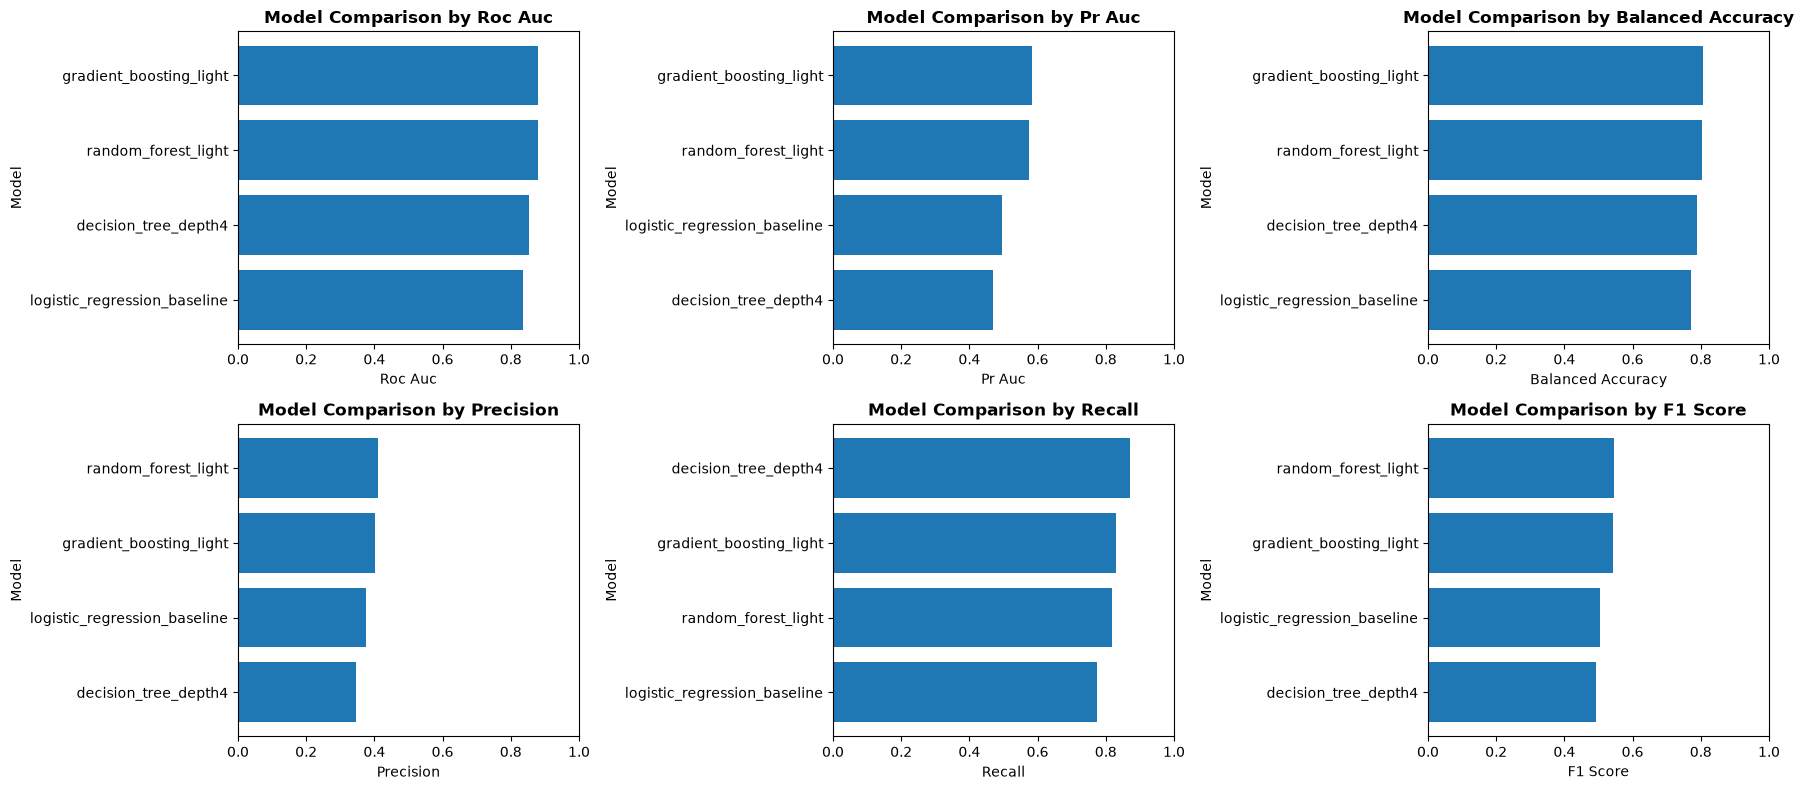

In [8]:
### supervised model - model comparison bar plots
metric_columns = [
    'roc_auc',
    'pr_auc',
    'balanced_accuracy',
    'precision',
    'recall',
    'f1_score'
]

fig, axes = plt.subplots(
    nrows = 2,
    ncols = 3,
    figsize = (18, 8)
)

axes = axes.flatten()

for ax, metric in zip(axes, metric_columns):

    plot_df = metrics_csv_friendly.sort_values(
        by = metric,
        ascending = True
    )

    ax.barh(
        plot_df['model'],
        plot_df[metric]
    )

    metric_label = metric.replace("_", " ").title()

    ax.set_title(
        f'Model Comparison by {metric_label}',
        fontweight = 'bold'
    )

    ax.set_xlabel(metric_label)
    ax.set_ylabel('Model')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

In [9]:
classification_metrics

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_positive,true_negative,false_positive,false_negative,predicted_positive_rate,confusion_matrix,classification_report
0,gradient_boosting_light,0.5,0.787978,0.805435,0.402587,0.830461,0.542287,0.879622,0.582389,1494,7879,2217,305,0.311980,"[[7879, 2217], [305, 1494]]",precision recall f1-score support\n\n 0 0.96 0.78 0.86 10096\n 1 0.40 0.83 0.54 1799\n\n accuracy 0.79 11895\n macro avg 0.68 0.81 0.70 11895\nweighted avg 0.88 0.79 0.81 11895\n
1,random_forest_light,0.5,0.793863,0.804333,0.409331,0.819344,0.545926,0.878701,0.576248,1474,7969,2127,325,0.302732,"[[7969, 2127], [325, 1474]]",precision recall f1-score support\n\n 0 0.96 0.79 0.87 10096\n 1 0.41 0.82 0.55 1799\n\n accuracy 0.79 11895\n macro avg 0.69 0.80 0.71 11895\nweighted avg 0.88 0.79 0.82 11895\n
2,logistic_regression_baseline,0.5,0.770828,0.772491,0.375236,0.774875,0.505622,0.837203,0.495532,1394,7775,2321,405,0.312316,"[[7775, 2321], [405, 1394]]",precision recall f1-score support\n\n 0 0.95 0.77 0.85 10096\n 1 0.38 0.77 0.51 1799\n\n accuracy 0.77 11895\n macro avg 0.66 0.77 0.68 11895\nweighted avg 0.86 0.77 0.80 11895\n
3,decision_tree_depth4,0.5,0.730307,0.787906,0.344858,0.870484,0.494006,0.853581,0.470244,1566,7121,2975,233,0.381757,"[[7121, 2975], [233, 1566]]",precision recall f1-score support\n\n 0 0.97 0.71 0.82 10096\n 1 0.34 0.87 0.49 1799\n\n accuracy 0.73 11895\n macro avg 0.66 0.79 0.66 11895\nweighted avg 0.87 0.73 0.77 11895\n


In [10]:
### supervised model - classification reports for baseline & benchmark models
for model_name in classification_metrics['model']:
    print(model_name)
    print(
        trainer
        .get_classification_report(model_name = model_name)
    )
    print()

gradient_boosting_light
              precision    recall  f1-score   support

           0       0.96      0.78      0.86     10096
           1       0.40      0.83      0.54      1799

    accuracy                           0.79     11895
   macro avg       0.68      0.81      0.70     11895
weighted avg       0.88      0.79      0.81     11895


random_forest_light
              precision    recall  f1-score   support

           0       0.96      0.79      0.87     10096
           1       0.41      0.82      0.55      1799

    accuracy                           0.79     11895
   macro avg       0.69      0.80      0.71     11895
weighted avg       0.88      0.79      0.82     11895


logistic_regression_baseline
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     10096
           1       0.38      0.77      0.51      1799

    accuracy                           0.77     11895
   macro avg       0.66      0.77      0.68     11895

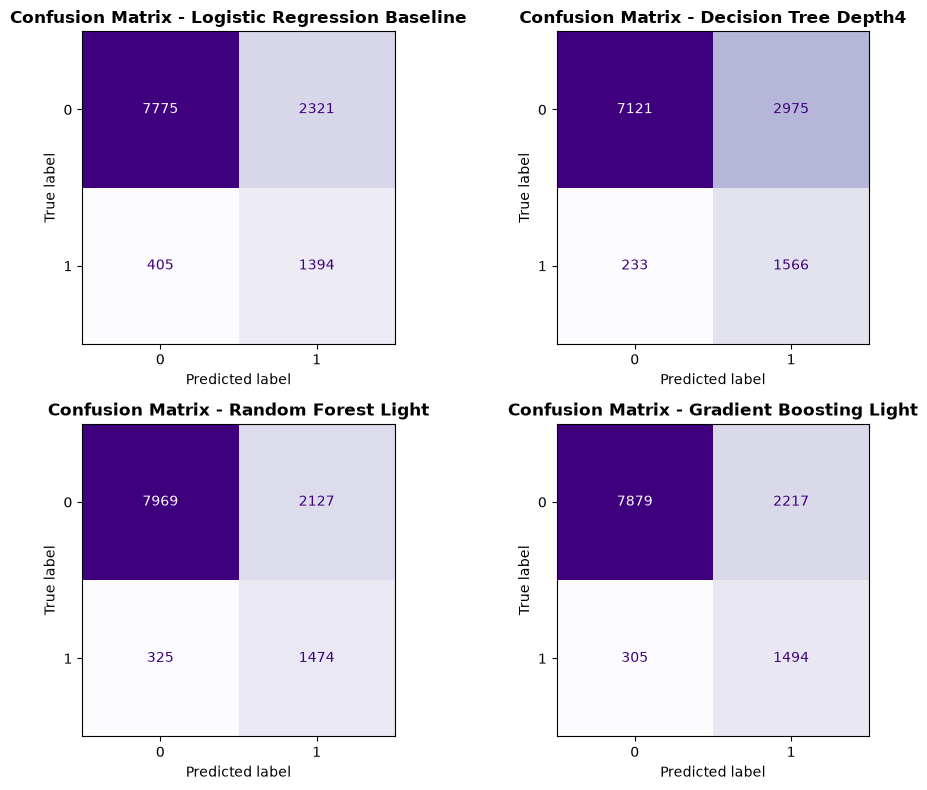

In [11]:
### supervised model - confusion matrices for baseline & benchmark models
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

n_models = len(trainer.trained_pipelines_)
n_cols = 2
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(
    nrows = n_rows,
    ncols = n_cols,
    figsize = (5 * n_cols, 4 * n_rows),
    squeeze = False
)

axes = axes.flatten()

for ax, (model_name, pipeline) in zip(axes, trainer.trained_pipelines_.items()):

    # get model predictions
    y_probability = pipeline.predict_proba(trainer.X_test_)[:, 1]
    y_prediction = (y_probability >= trainer.threshold).astype(int)

    ConfusionMatrixDisplay.from_predictions(
        y_true = trainer.y_test_,
        y_pred = y_prediction,
        values_format = 'd',
        cmap = 'Purples',
        ax = ax,
        colorbar = False
    )

    model_label = model_name.replace("_", " ").title()

    ax.set_title(
        f'Confusion Matrix - {model_label}',
        fontweight = 'bold'
    )

plt.tight_layout()
plt.show()

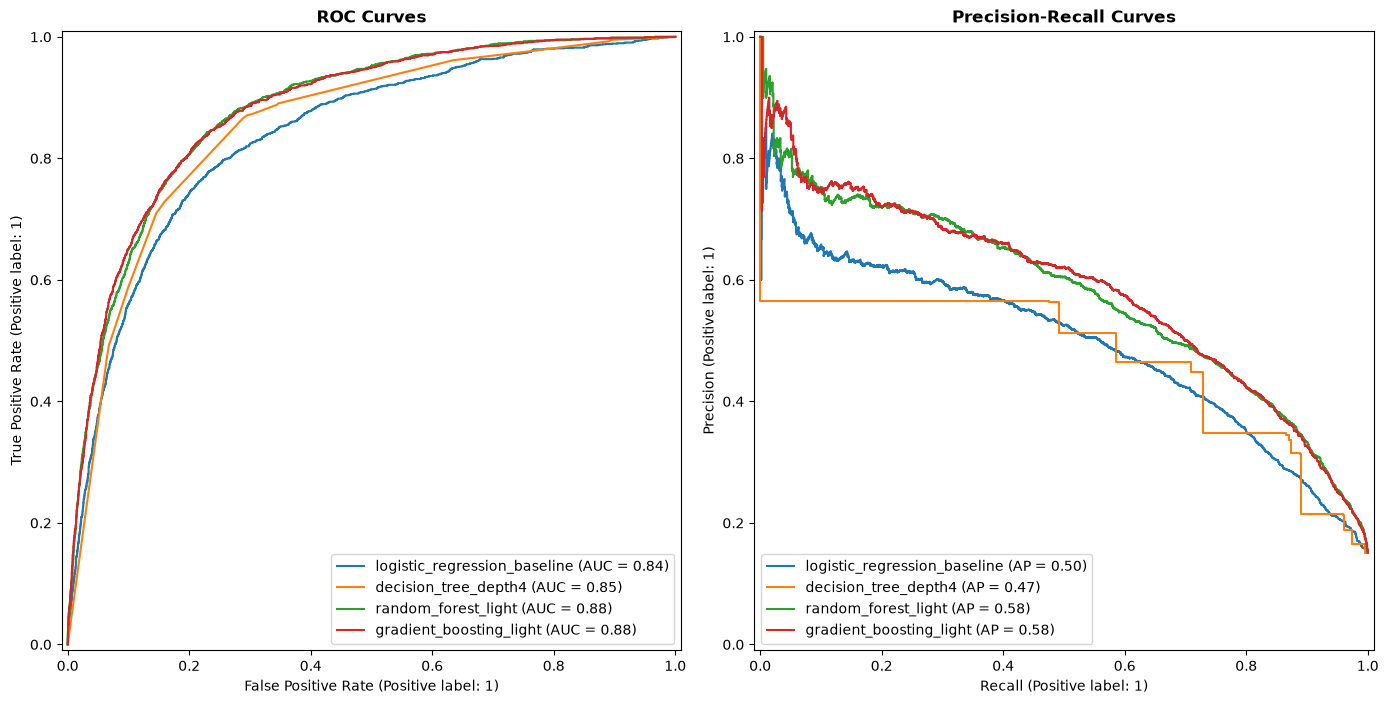

In [12]:
### supervised model - ROC & precision-recall curves for baseline & benchmark models
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

fig, axes = plt.subplots(
    nrows = 1,
    ncols = 2,
    figsize = (7 * n_cols, 5 * n_rows),
    squeeze = False
)

ax_roc = axes[0, 0]
ax_pr = axes[0, 1]

for model_name, pipeline in trainer.trained_pipelines_.items():

    RocCurveDisplay.from_estimator(
        estimator = pipeline,
        X = trainer.X_test_,
        y = trainer.y_test_,
        name = model_name,
        ax = ax_roc
    )

    PrecisionRecallDisplay.from_estimator(
        estimator = pipeline,
        X = trainer.X_test_,
        y = trainer.y_test_,
        name = model_name,
        ax = ax_pr
    )

ax_roc.set_title(
    'ROC Curves',
    fontweight = 'bold'
)

ax_pr.set_title(
    'Precision-Recall Curves',
    fontweight = 'bold'
)

plt.tight_layout()
plt.show()

In [13]:
### supervised model - threshold sensitivity for the baseline model (Logistic Regression Classifier)
if trainer.X_test_ is None:
    raise ValueError('X_test_ is not available, please fit the trainer first!')
if trainer.y_test_ is None:
    raise ValueError('y_test_ is not available, please fit the trainer first!')

baseline_model_name = 'logistic_regression_baseline'
baseline_pipeline = trainer.trained_pipelines_[baseline_model_name]

y_probability = baseline_pipeline.predict_proba(trainer.X_test_)[:, 1]

thresholds = np.arange(0.25, 0.76, 0.05)

threshold_results = []

for threshold in thresholds:

    # get predictions
    y_prediction = (y_probability >= threshold).astype(int)

    tp = (
        (trainer.y_test_ == 1) & (y_prediction == 1)
    ).sum()

    tn = (
        (trainer.y_test_ == 0) & (y_prediction == 0)
    ).sum()

    fp = (
        (trainer.y_test_ == 0) & (y_prediction == 1)
    ).sum()

    fn = (
        (trainer.y_test_ == 1) & (y_prediction == 0)
    ).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    predicted_positive_rate = y_prediction.mean()

    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'predicted_positive_rate': predicted_positive_rate,
        'false_positive': fp,
        'false_negative': fn,
        'true_positive': tp,
        'true_negative': tn
    })

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df

,threshold,precision,recall,predicted_positive_rate,false_positive,false_negative,true_positive,true_negative
0,0.25,0.240431,0.918288,0.577638,5219,147,1652,4877
1,0.30,0.272109,0.889383,0.494325,4280,199,1600,5816
2,0.35,0.308869,0.842135,0.412358,3390,284,1515,6706
3,0.40,0.340401,0.812118,0.360824,2831,338,1461,7265
4,0.45,0.359889,0.790995,0.332409,2531,376,1423,7565
5,0.50,0.375236,0.774875,0.312316,2321,405,1394,7775
6,0.55,0.396226,0.747082,0.285162,2048,455,1344,8048
7,0.60,0.422222,0.707615,0.253468,1742,526,1273,8354
8,0.65,0.452298,0.650917,0.217654,1418,628,1171,8678
9,0.70,0.481481,0.592551,0.186129,1148,733,1066,8948


* threshold selection should be linked to business objectives; therefore, the investigation capacity. As we impose a stricter threshold, we can observe the bump in precision, but at the expense of missing true_positives, which might be costly for the business as well as the reputational damage that the bank may face. Likewise, a looser threshold may increase the recall rate significantly, but poses another threat such as customer friction for the business.

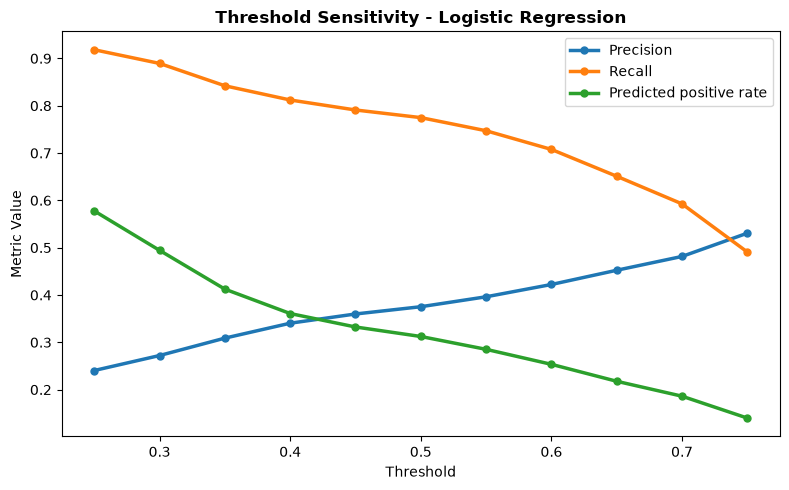

In [14]:
### supervised model - threshold sensitivity plot for the baseline model (Logistic Regression Classifier)
plt.figure(figsize = (8, 5))

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['precision'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Precision'
)

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['recall'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Recall'
)

plt.plot(
    threshold_results_df['threshold'],
    threshold_results_df['predicted_positive_rate'],
    marker = 'o',
    markersize = 5,
    linewidth = 2.5,
    label = 'Predicted positive rate'
)

plt.title(
    'Threshold Sensitivity - Logistic Regression',
    fontweight = 'bold'
)
plt.xlabel('Threshold')
plt.ylabel('Metric Value')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
### supervised model - save metrics into a notebook summary table
metrics_csv_friendly.to_csv(
    METRICS_DIR / "supervised_model_metrics_notebook_summary.csv",
    index=False,
)

threshold_results_df.to_csv(
    METRICS_DIR / "logistic_regression_threshold_sensitivity.csv",
    index=False,
)